In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# from langchain_openai import AzureChatOpenAI

# llm = AzureChatOpenAI(
#     azure_deployment='gpt-4o-2024-11-20',
#     api_version='2024-08-01-preview',   
# )

# small_llm = AzureChatOpenAI(
#     azure_deployment='gpt-4o-mini-2024-07-18',
#     api_version='2024-08-01-preview',
# )
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-5.4')
small_llm = ChatOpenAI(model='gpt-5.4-mini')

In [3]:
%pip install --upgrade --quiet  yfinance

Note: you may need to restart the kernel to use updated packages.


In [4]:
from typing import Literal
from langchain_community.tools.yahoo_finance_news import YahooFinanceNewsTool
from langchain.agents import create_agent
from langchain_core.messages import HumanMessage
from langgraph.graph.message import MessagesState
from langgraph.types import Command
# from langchain_community.agent_toolkits.polygon.toolkit import PolygonToolkit
# from langchain_community.utilities.polygon import PolygonAPIWrapper

# # Polygon API를 초기화합니다.
# polygon = PolygonAPIWrapper()

# # Polygon API로부터 도구 모음을 생성합니다.
# toolkit = PolygonToolkit.from_polygon_api_wrapper(polygon)

# # 도구들을 가져옵니다.
# polygon_tools = toolkit.get_tools()

# 시장 조사 도구 목록을 생성합니다.
market_research_tools = [YahooFinanceNewsTool()]

# 시장 조사 에이전트를 생성합니다.
market_research_agent = create_agent(
    llm, 
    tools=market_research_tools, 
    system_prompt='You are a market researcher. provide fact only not opinions'
    )

def market_research_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    # """
    # 시장 조사 node입니다. 주어진 state를 기반으로 시장 조사 에이전트를 호출하고,
    # 결과를 supervisor node로 전달합니다.

    # Args:
    #     state (MessagesState): 현재 메시지 상태를 나타내는 객체입니다.

    # Returns:
    #     Command: supervisor node로 이동하기 위한 명령을 반환합니다.
    # """
    # 시장 조사 에이전트를 호출하여 결과를 얻습니다.
    result = market_research_agent.invoke(state)

    print(f"market_research == {result}")
    
    # 결과 메시지를 업데이트하고 supervisor node로 이동합니다.
    return Command(
        update={'messages': [HumanMessage(content=result['messages'][-1].content, name='market_research')]},
        goto='supervisor'
    )

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [5]:
import yfinance as yf

from langchain.tools import tool

@tool
def get_stock_price(ticker: str) -> dict:
    """Given a stock ticker, return the price data for the past month"""
    stock_info = yf.download(ticker, period='1mo').to_dict()
    return stock_info


stock_research_tools = [get_stock_price]
stock_research_agent = create_agent(
    llm, tools=stock_research_tools, system_prompt='You are a stock researcher. provide fact only not opinions'
)

def stock_research_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    """
    주식 조사 node입니다. 주어진 State를 기반으로 주식 조사 에이전트를 호출하고,
    결과를 supervisor node로 전달합니다.

    Args:
        state (MessagesState): 현재 메시지 상태를 나타내는 객체입니다.

    Returns:
        Command: supervisor node로 이동하기 위한 명령을 반환합니다.
    """
    result = stock_research_agent.invoke(state)

    return Command(
        update={'messages': [HumanMessage(content=result['messages'][-1].content, name='stock_research')]},
        goto='supervisor'
    )

In [6]:
@tool
def company_research_tool(ticker: str) -> dict:
    """Given a ticker, return the financial information and SEC filings"""
    company_info = yf.Ticker(ticker)
    financial_info = company_info.get_financials()
    sec_filings = company_info.get_sec_filings()
    return {
        'financial_info': financial_info,
        'sec_filings': sec_filings
    }

company_research_tools = [company_research_tool]
company_research_agent = create_agent(
    llm, tools=company_research_tools, system_prompt='You are a company researcher. Provide facts only not opinions'
)

def company_research_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    """
    회사 조사 node입니다. 주어진 State를 기반으로 회사 조사 에이전트를 호출하고,
    결과를 supervisor node로 전달합니다.

    Args:
        state (MessagesState): 현재 메시지 상태를 나타내는 객체입니다.

    Returns:
        Command: supervisor node로 이동하기 위한 명령을 반환합니다.
    """
    result = company_research_agent.invoke(state)

    return Command(
        update={'messages': [HumanMessage(content=result['messages'][-1].content, name='company_research')]},
        goto='supervisor'
    )

In [7]:
# from langchain_core.prompts import PromptTemplate

# analyst_prompt = PromptTemplate.from_template(
#     """You are a stock market analyst. Given the following information, 
# Please decide wheter to buy, sell, or hold the stock.

# Information:
# {messages}"""
# )

# analyst_chain = analyst_prompt | llm

# def analyst_node(state: MessagesState):
#     """
#     분석가 node입니다. 주어진 State를 기반으로 분석가 체인을 호출하고,
#     결과 메시지를 반환합니다.

#     Args:
#         state (MessagesState): 현재 메시지 상태를 나타내는 객체입니다.

#     Returns:
#         dict: 분석 결과 메시지를 포함하는 딕셔너리를 반환합니다.
#     """
#     result = analyst_chain.invoke({'messages': state['messages'][1:]})

#     return {'messages': [result]}

In [8]:
from typing import Literal
from typing_extensions import TypedDict

from langgraph.graph import MessagesState, END
from langgraph.types import Command


members = ["market_research", "stock_research", "company_research"]
options = members + ["FINISH"]

# system_prompt = (
#     "You are a supervisor tasked with managing a conversation between the"
#     f" following workers: {members}. Given the following user request,"
#     " respond with the worker to act next. Each worker will perform a"
#     " task and respond with their results and status. When finished,"
#     " respond with FINISH."
# )

system_prompt = (
    "You are a supervisor tasked with managing workers: "
    f"{members}. "
    "Always choose one worker before FINISH. "
    "If the question is about investment, first call market_research, "
    "then stock_research, then company_research, and finally FINISH."
)


class Router(TypedDict):
    """Worker to route to next. If no workers needed, route to FINISH."""

    next: Literal[*options]



def supervisor_node(state: MessagesState) -> Command[Literal[*members, "__end__"]]:
    messages = [
        {"role": "system", "content": system_prompt},
    ] + state['messages']
    response = llm.with_structured_output(Router).invoke(messages)
    goto = response["next"]
    if goto == "FINISH":
        goto = END

    return Command(goto=goto)

In [9]:
from langgraph.graph import StateGraph, START

graph_builder = StateGraph(MessagesState)

graph_builder.add_node("supervisor", supervisor_node)
graph_builder.add_node("market_research", market_research_node)
graph_builder.add_node("stock_research", stock_research_node)
graph_builder.add_node("company_research", company_research_node)
# graph_builder.add_node("analyst", analyst_node)

In [10]:
graph_builder.add_edge(START, "supervisor")
# graph_builder.add_edge("analyst", END)
graph = graph_builder.compile()


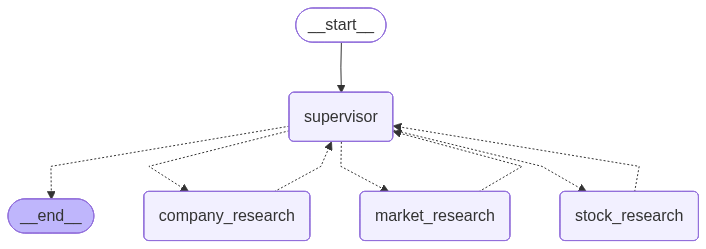

In [11]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))


In [12]:
for chunk in graph.stream(
    {"messages": [("user", "Would you invest in Snowflake?")]}, stream_mode="values"
):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

Would you invest in Snowflake?
market_research == {'messages': [HumanMessage(content='Would you invest in Snowflake?', additional_kwargs={}, response_metadata={}, id='428c6f33-fec4-4559-b46e-d667731a9d18'), AIMessage(content='I can provide factual market-research information about Snowflake, but I should not give a personal investment opinion or recommendation.\n\nIf helpful, I can give you a fact-based summary of Snowflake covering:\n\n- Business model\n- Recent revenue growth\n- Profitability and cash flow\n- Valuation metrics\n- Competitive landscape\n- Recent company news\n- Key risks\n\nIf you want, I can also pull recent financial news on Snowflake and summarize it.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 95, 'prompt_tokens': 184, 'total_tokens': 279, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_to